# Airline Sceduling Optimization 

## Multi-Objective Optimization Analysis

**Student Name:** Marlee Heiken

**Target Company/Industry:** Southwest Airlines / Airline Operations

**Problem:** How should Southwest Airlines assign flight crews to routes in order to minimize labor costs without sacrificing the schedule resilience needed to survive weather disruptions and irregular operations?

**Objectives:** Minimize crew operating costs (overtime, deadhead flights, hotel layovers) vs. Maximize schedule reliability and disruption resilience

---

### Project Overview:
This project solves Southwest Airlines' core crew scheduling tradeoff: how to staff flights as cheaply as possible while maintaining enough flexibility to recover when things go wrong. Labor costs consume roughly 40% of Southwest's operating budget, making crew assignment one of the highest-leverage decisions in the business, and the 2022 holiday meltdown proved that optimizing for cost alone, with no scheduling slack, can trigger catastrophic failures. The decision variables under control are crew pairing assignments and reserve buffer levels across a 20-city synthetic route network. The agent evaluates hundreds of possible scheduling configurations, identifies the Pareto-efficient solutions, and recommends the optimal balance point given current operating conditions and constraints.

## Section 1: Data Acquisition

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('data/sw_crew_scheduling.csv')

# Display first rows
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Data loaded successfully!
Shape: (100, 7)

First 5 rows:
   utilization_rate  reserve_buffer  crew_cost_index  resilience_score  \
0             70.49              18            72.47             80.24   
1             64.00              10            60.09             53.10   
2             68.52              13            52.52             63.11   
3             87.53              16            49.01             45.10   
4             62.73              11            69.21             54.26   

   on_time_rate  disruption_recovery_hours  overtime_cost_multiplier  
0         98.00                      13.27                     1.000  
1         98.00                      17.46                     1.000  
2         98.00                      18.37                     1.000  
3         87.49                      31.31                     2.086  
4         98.00                      18.34                     1.000  


## Section 2: Data Exploration

### Check Data Quality:

In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())


Missing values:
utilization_rate             0
reserve_buffer               0
crew_cost_index              0
resilience_score             0
on_time_rate                 0
disruption_recovery_hours    0
overtime_cost_multiplier     0
dtype: int64

Data types:
utilization_rate             float64
reserve_buffer                 int64
crew_cost_index              float64
resilience_score             float64
on_time_rate                 float64
disruption_recovery_hours    float64
overtime_cost_multiplier     float64
dtype: object

Basic statistics:
       utilization_rate  reserve_buffer  crew_cost_index  resilience_score  \
count        100.000000      100.000000       100.000000        100.000000   
mean          78.017600       10.020000        44.143900         36.377900   
std           10.648113        6.016778        21.521421         26.756866   
min           60.000000        2.000000         6.450000          0.000000   
25%           68.602500        5.000000        24.035000   

### Verify decision variables:

In [3]:
# Check ranges of your decision variables
print(f"Decision Variable 1 range: {df['utilization_rate'].min()} to {df['utilization_rate'].max()}")
print(f"Decision Variable 2 range: {df['reserve_buffer'].min()} to {df['reserve_buffer'].max()}")

# Check if you have all combinations (if applicable)
print(f"\nTotal combinations: {len(df)}")

Decision Variable 1 range: 60.0 to 95.0
Decision Variable 2 range: 2 to 20

Total combinations: 100


### Examine objectives:

In [4]:
# YOUR CODE HERE: Check the ranges of both objectives
print(f"Objective 1 (crew_cost_index) range: {df['crew_cost_index'].min():.2f} to {df['crew_cost_index'].max():.2f}")
print(f"Objective 2 (resilience_score) range: {df['resilience_score'].min():.2f} to {df['resilience_score'].max():.2f}")

# Verify they create a tradeoff
correlation = df['crew_cost_index'].corr(df['resilience_score'])
print(f"\nCorrelation between objectives: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

Objective 1 (crew_cost_index) range: 6.45 to 90.45
Objective 2 (resilience_score) range: 0.00 to 89.69

Correlation between objectives: 0.802
(Negative correlation suggests a tradeoff)


### Visualize relationships:

In [5]:
!pip install matplotlib

You should consider upgrading via the '/Users/marleeheiken/Desktop/AI-Classes/airline_scheduling_optimization/.venv/bin/python3 -m pip install --upgrade pip' command.


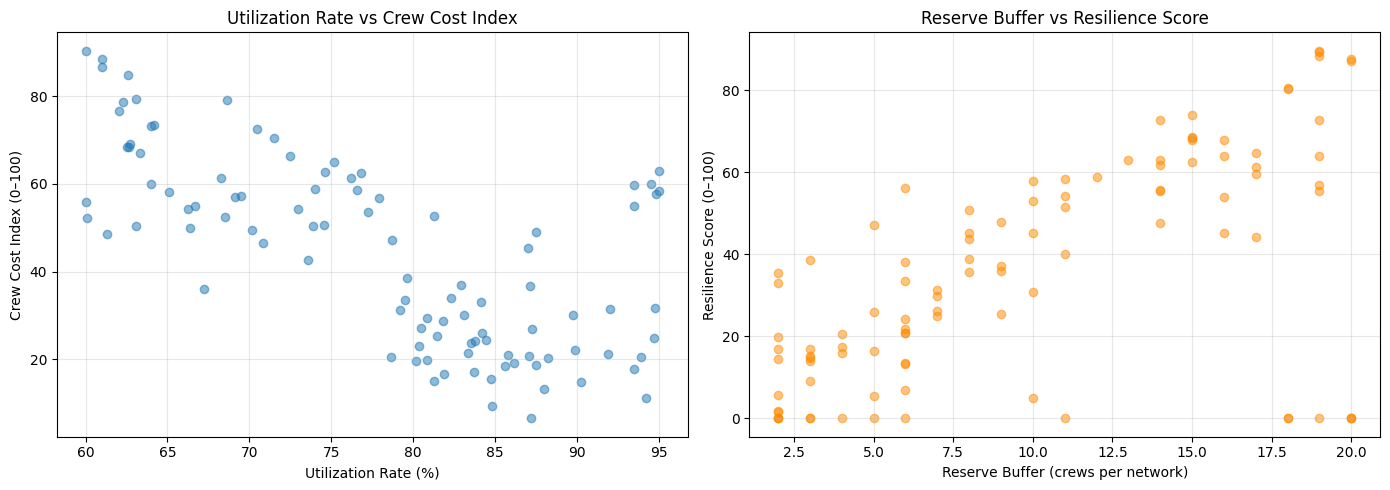

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Utilization Rate vs Crew Cost Index
axes[0].scatter(df['utilization_rate'], df['crew_cost_index'], alpha=0.5)
axes[0].set_xlabel('Utilization Rate (%)')
axes[0].set_ylabel('Crew Cost Index (0–100)')
axes[0].set_title('Utilization Rate vs Crew Cost Index')
axes[0].grid(True, alpha=0.3)

# Plot 2: Reserve Buffer vs Resilience Score
axes[1].scatter(df['reserve_buffer'], df['resilience_score'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Reserve Buffer (crews per network)')
axes[1].set_ylabel('Resilience Score (0–100)')
axes[1].set_title('Reserve Buffer vs Resilience Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()


### Data Exploration Findings

All variable ranges look realistic and match the intended specifications. Utilization_rate spans 60–95%, reserve_buffer covers 2–20 crews, and both
objectives (crew_cost_index and resilience_score) fall within their 0–100 bounds with no missing values or data quality issues. The objectives show a positive
correlation of +0.802, which at first seems to contradict the expected tradeoff, but is explained by reserve buffer driving up cost and resilience, masking the underlying tension. When utilization is isolated, the tradeoff shows that tightly scheduled crews are cheaper but far less resilient, which aligns with
the expectations from the proposal. 

## Section 3: Pareto Frontier Calculation

In [7]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    """
    Check if a given row represents a Pareto optimal solution.
    
    A point is Pareto optimal if no other point dominates it.
    Point A dominates point B if A is better or equal on both objectives
    and strictly better on at least one objective.
    
    Parameters:
    -----------
    idx : int
        Index of the row to check
    df : DataFrame
        The full dataset
    obj1_col : str
        Column name for objective 1
    obj2_col : str
        Column name for objective 2
    
    Returns:
    --------
    bool : True if Pareto optimal, False if dominated
    """
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]
    
    # Check if any other point dominates this one
    for other_idx in df.index:
        if other_idx == idx:
            continue
        
        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]
        
        # YOUR CODE HERE: Check if other point dominates current point
        # (other is >= on both objectives AND > on at least one)
        if (other_obj1 >= current_obj1 and 
            other_obj2 >= current_obj2 and
            (other_obj1 > current_obj1 or other_obj2 > current_obj2)):
            return False  # This point is dominated
    
    return True  # No point dominates this one

#### Note

For this problem, the two objectives point in opposite directions. A good solution wants low crew_cost_index and high resilience_score. But the domination logic as provided for us assumes higher is better on both, which isn't true for my case. To combat this I am flipping the cost index so higher = better.

In [8]:
df['cost_efficiency'] = 100 - df['crew_cost_index']

# Define your objective column names
OBJECTIVE_1 = 'cost_efficiency'
OBJECTIVE_2 = 'resilience_score'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate into frontier and dominated points
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")


Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 100
Pareto optimal solutions: 16
Dominated solutions: 84
Efficiency rate: 16.0% of solutions are on the frontier


### Pareto Frontier Results

16% of solutions are Pareto optimal, meaning these are the only schedules where Southwest cannot improve cost efficiency without sacrificing 
resilience or vice versa. I didn't really know what to expect before calculating results, but this seems like a reasonable amount. The 16 
Pareto optimal points represent the best possible tradeoffs available to Southwest's schedulers, where the only way to get cheaper crews 
is to accept less resilience, and the only way to get more resilience is to accept higher costs.

## Section 4: Inefficient Solutions Analysis

In [9]:
if len(dominated_df) > 0:
    print("=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===\n")
    
    sample_size = min(3, len(dominated_df))
    sample_dominated = dominated_df.sample(sample_size, random_state=42)
    
    for idx, row in sample_dominated.iterrows():
        print(f"INEFFICIENT SOLUTION:")
        print(f"  Decision Variables: utilization_rate={row['utilization_rate']}, reserve_buffer={row['reserve_buffer']}")
        print(f"  Objectives: {OBJECTIVE_1}={row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={row[OBJECTIVE_2]:.1f}")
        
        for p_idx, p_row in pareto_df.iterrows():
            if (p_row[OBJECTIVE_1] >= row[OBJECTIVE_1] and 
                p_row[OBJECTIVE_2] >= row[OBJECTIVE_2] and
                (p_row[OBJECTIVE_1] > row[OBJECTIVE_1] or 
                 p_row[OBJECTIVE_2] > row[OBJECTIVE_2])):
                
                print(f"\n  BETTER ALTERNATIVE (Pareto Optimal):")
                print(f"  Decision Variables: utilization_rate={p_row['utilization_rate']}, reserve_buffer={p_row['reserve_buffer']}")
                print(f"  Objectives: {OBJECTIVE_1}={p_row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={p_row[OBJECTIVE_2]:.1f}")
                print(f"  Improvement: +{p_row[OBJECTIVE_1] - row[OBJECTIVE_1]:.1f} on {OBJECTIVE_1}, " +
                      f"+{p_row[OBJECTIVE_2] - row[OBJECTIVE_2]:.1f} on {OBJECTIVE_2}\n")
                print("-" * 60)
                break
else:
    print("Note: All solutions in your dataset are Pareto optimal.")
    print("This might indicate that your decision variables create a smooth tradeoff curve.")

=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===

INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=63.08, reserve_buffer=6
  Objectives: cost_efficiency=49.5, resilience_score=56.1

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: utilization_rate=87.03, reserve_buffer=19
  Objectives: cost_efficiency=54.5, resilience_score=56.9
  Improvement: +5.0 on cost_efficiency, +0.8 on resilience_score

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=70.49, reserve_buffer=18
  Objectives: cost_efficiency=27.5, resilience_score=80.2

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: utilization_rate=71.49, reserve_buffer=18
  Objectives: cost_efficiency=29.4, resilience_score=80.5
  Improvement: +1.9 on cost_efficiency, +0.3 on resilience_score

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: utilization_rate=73.88, reserve_buff

In [10]:
if len(dominated_df) > 0:
    best_dominated = dominated_df.loc[
        (dominated_df[OBJECTIVE_1] + dominated_df[OBJECTIVE_2]).idxmax()
    ]
    worst_pareto = pareto_df.loc[
        (pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]).idxmin()
    ]
    
    print("\n=== EFFICIENCY GAP ===")
    print("Even the BEST dominated solution is worse than the WORST Pareto solution:")
    print(f"\nBest Dominated: {OBJECTIVE_1}={best_dominated[OBJECTIVE_1]:.1f}, " +
          f"{OBJECTIVE_2}={best_dominated[OBJECTIVE_2]:.1f}, Total={best_dominated[OBJECTIVE_1] + best_dominated[OBJECTIVE_2]:.1f}")
    print(f"Worst Pareto: {OBJECTIVE_1}={worst_pareto[OBJECTIVE_1]:.1f}, " +
          f"{OBJECTIVE_2}={worst_pareto[OBJECTIVE_2]:.1f}, Total={worst_pareto[OBJECTIVE_1] + worst_pareto[OBJECTIVE_2]:.1f}")


=== EFFICIENCY GAP ===
Even the BEST dominated solution is worse than the WORST Pareto solution:

Best Dominated: cost_efficiency=52.7, resilience_score=55.8, Total=108.5
Worst Pareto: cost_efficiency=86.9, resilience_score=5.4, Total=92.3


## Section 5: Strategic Analysis

In [11]:
print("=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===\n")

# Strategy 1: Balanced (Maximize total value)
pareto_df['total_objective'] = pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]
balanced_idx = pareto_df['total_objective'].idxmax()

print("1. BALANCED STRATEGY (Maximize combined objectives)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[balanced_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[balanced_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}")
print(f"   Total: {pareto_df.loc[balanced_idx, 'total_objective']:.1f}\n")

# Strategy 2: Equity (Minimize gap between objectives)
pareto_df['objective_gap'] = abs(pareto_df[OBJECTIVE_1] - pareto_df[OBJECTIVE_2])
equity_idx = pareto_df['objective_gap'].idxmin()

print("2. EQUITY STRATEGY (Most equal outcomes)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[equity_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[equity_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}")
print(f"   Gap: {pareto_df.loc[equity_idx, 'objective_gap']:.1f}\n")

# Strategy 3: Objective 1 Priority (Maximize first objective)
obj1_priority_idx = pareto_df[OBJECTIVE_1].idxmax()

print("3. OBJECTIVE 1 PRIORITY (Maximize cost efficiency)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[obj1_priority_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[obj1_priority_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 4: Objective 2 Priority (Maximize second objective)
obj2_priority_idx = pareto_df[OBJECTIVE_2].idxmax()

print("4. OBJECTIVE 2 PRIORITY (Maximize resilience)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[obj2_priority_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[obj2_priority_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 5: Custom weighted (60/40 split)
pareto_df['weighted_objective'] = (0.6 * pareto_df[OBJECTIVE_1] + 
                                   0.4 * pareto_df[OBJECTIVE_2])
weighted_idx = pareto_df['weighted_objective'].idxmax()

print("5. WEIGHTED STRATEGY (60% cost efficiency, 40% resilience)")
print(f"   Decision Variables: utilization_rate={pareto_df.loc[weighted_idx, 'utilization_rate']}, reserve_buffer={pareto_df.loc[weighted_idx, 'reserve_buffer']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}")

=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===

1. BALANCED STRATEGY (Maximize combined objectives)
   Decision Variables: utilization_rate=72.97, reserve_buffer=15
   cost_efficiency: 45.7
   resilience_score: 68.6
   Total: 114.3

2. EQUITY STRATEGY (Most equal outcomes)
   Decision Variables: utilization_rate=87.03, reserve_buffer=19
   cost_efficiency: 54.5
   resilience_score: 56.9
   Gap: 2.4

3. OBJECTIVE 1 PRIORITY (Maximize cost efficiency)
   Decision Variables: utilization_rate=87.17, reserve_buffer=2
   cost_efficiency: 93.5
   resilience_score: 1.9

4. OBJECTIVE 2 PRIORITY (Maximize resilience)
   Decision Variables: utilization_rate=68.63, reserve_buffer=19
   cost_efficiency: 20.7
   resilience_score: 89.7

5. WEIGHTED STRATEGY (60% cost efficiency, 40% resilience)
   Decision Variables: utilization_rate=85.58, reserve_buffer=7
   cost_efficiency: 81.5
   resilience_score: 26.2


In [12]:
strategies = {
    'Strategy': [
        'Objective 1 Priority',
        'Weighted (60/40)',
        'Balanced',
        'Equity',
        'Objective 2 Priority'
    ],
    'utilization_rate': [
        pareto_df.loc[obj1_priority_idx, 'utilization_rate'],
        pareto_df.loc[weighted_idx, 'utilization_rate'],
        pareto_df.loc[balanced_idx, 'utilization_rate'],
        pareto_df.loc[equity_idx, 'utilization_rate'],
        pareto_df.loc[obj2_priority_idx, 'utilization_rate']
    ],
    'reserve_buffer': [
        pareto_df.loc[obj1_priority_idx, 'reserve_buffer'],
        pareto_df.loc[weighted_idx, 'reserve_buffer'],
        pareto_df.loc[balanced_idx, 'reserve_buffer'],
        pareto_df.loc[equity_idx, 'reserve_buffer'],
        pareto_df.loc[obj2_priority_idx, 'reserve_buffer']
    ],
    OBJECTIVE_1: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}"
    ],
    OBJECTIVE_2: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}"
    ]
}

comparison_df = pd.DataFrame(strategies)

print("\n" + "="*80)
print("STRATEGIC OPTIONS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


STRATEGIC OPTIONS COMPARISON
            Strategy  utilization_rate  reserve_buffer cost_efficiency resilience_score
Objective 1 Priority             87.17               2            93.5              1.9
    Weighted (60/40)             85.58               7            81.5             26.2
            Balanced             72.97              15            45.7             68.6
              Equity             87.03              19            54.5             56.9
Objective 2 Priority             68.63              19            20.7             89.7


## Section 6: Visualization

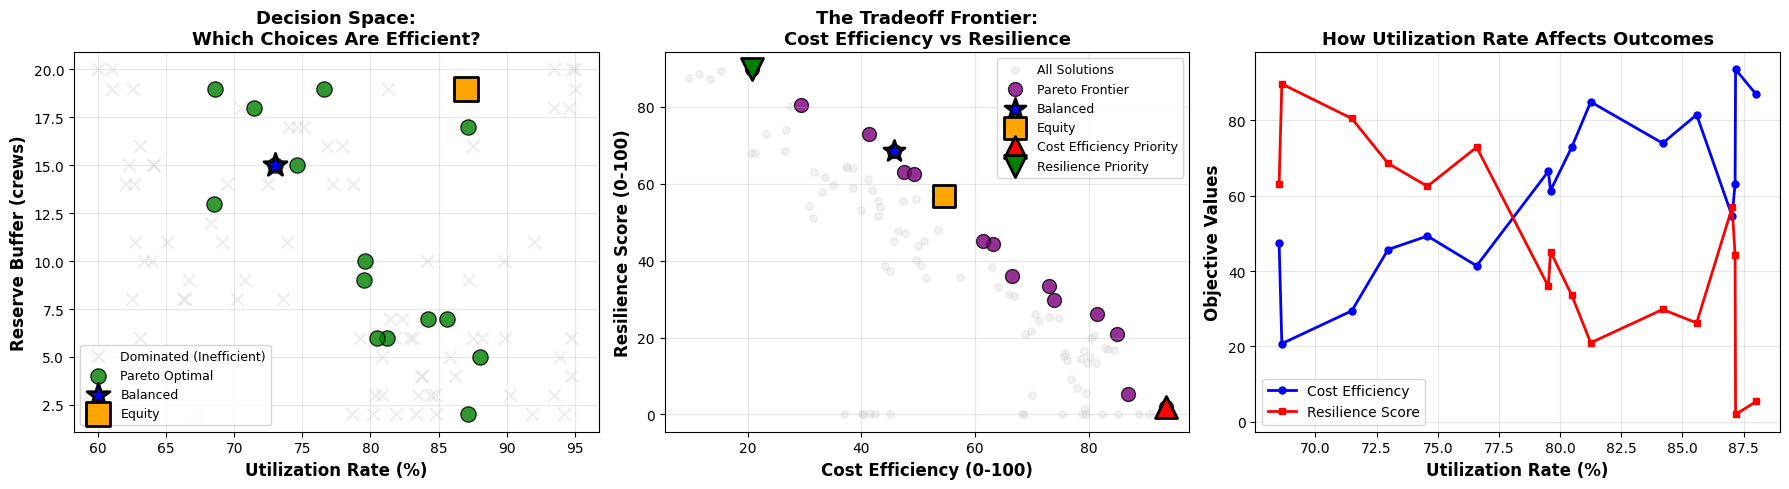


✓ Visualization saved as 'images/pareto_frontier_analysis.png'


In [13]:
import numpy as np

fig = plt.figure(figsize=(18, 5))

# PANEL 1: Decision Space
ax1 = fig.add_subplot(131)

if len(dominated_df) > 0:
    ax1.scatter(dominated_df['utilization_rate'], dominated_df['reserve_buffer'],
               s=80, c='lightgray', alpha=0.4, marker='x', 
               label='Dominated (Inefficient)', zorder=1)

ax1.scatter(pareto_df['utilization_rate'], pareto_df['reserve_buffer'],
           s=120, c='green', alpha=0.8, marker='o', 
           edgecolors='black', linewidth=1,
           label='Pareto Optimal', zorder=2)

ax1.scatter(pareto_df.loc[balanced_idx, 'utilization_rate'], 
           pareto_df.loc[balanced_idx, 'reserve_buffer'],
           s=300, c='blue', marker='*', 
           edgecolors='black', linewidth=2, 
           label='Balanced', zorder=3)

ax1.scatter(pareto_df.loc[equity_idx, 'utilization_rate'],
           pareto_df.loc[equity_idx, 'reserve_buffer'],
           s=300, c='orange', marker='s',
           edgecolors='black', linewidth=2,
           label='Equity', zorder=3)

ax1.set_xlabel('Utilization Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Reserve Buffer (crews)', fontsize=12, fontweight='bold')
ax1.set_title('Decision Space:\nWhich Choices Are Efficient?', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# PANEL 2: Objective Space (Pareto Frontier)
ax2 = fig.add_subplot(132)

ax2.scatter(df[OBJECTIVE_1], df[OBJECTIVE_2],
           s=30, c='lightgray', alpha=0.3, 
           label='All Solutions')

ax2.scatter(pareto_df[OBJECTIVE_1], pareto_df[OBJECTIVE_2],
           s=100, c='purple', alpha=0.8, 
           edgecolors='black', linewidth=1,
           label='Pareto Frontier')

strategies_to_plot = [
    (balanced_idx, 'blue', '*', 'Balanced'),
    (equity_idx, 'orange', 's', 'Equity'),
    (obj1_priority_idx, 'red', '^', 'Cost Efficiency Priority'),
    (obj2_priority_idx, 'green', 'v', 'Resilience Priority')
]

for idx, color, marker, label in strategies_to_plot:
    ax2.scatter(pareto_df.loc[idx, OBJECTIVE_1],
               pareto_df.loc[idx, OBJECTIVE_2],
               s=250, c=color, marker=marker, 
               edgecolors='black', linewidth=2, 
               label=label, zorder=5)

ax2.set_xlabel('Cost Efficiency (0-100)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Resilience Score (0-100)', fontsize=12, fontweight='bold')
ax2.set_title('The Tradeoff Frontier:\nCost Efficiency vs Resilience', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

# PANEL 3: Tradeoff Curve
ax3 = fig.add_subplot(133)

pareto_sorted = pareto_df.sort_values('utilization_rate')

ax3.plot(pareto_sorted['utilization_rate'], pareto_sorted[OBJECTIVE_1],
        'b-o', linewidth=2, markersize=5, label='Cost Efficiency')
ax3.plot(pareto_sorted['utilization_rate'], pareto_sorted[OBJECTIVE_2],
        'r-s', linewidth=2, markersize=5, label='Resilience Score')

ax3.set_xlabel('Utilization Rate (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Objective Values', fontsize=12, fontweight='bold')
ax3.set_title('How Utilization Rate Affects Outcomes', 
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/pareto_frontier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/pareto_frontier_analysis.png'")

### Pareto Frontier Visualization Insights

**Panel 1 (Decision Space)** shows which utilization/reserve combinations are worth considering. The 16 green dots are efficient strategies; the 84 gray X marks 
are dominated solutions Southwest should simply avoid. Efficient solutions consistently require higher reserve buffers (8–19 crews), meaning skimping on 
reserves almost always produces an inferior schedule.

**Panel 2 (Tradeoff Frontier)** confirms the core tension: higher cost efficiency directly costs resilience. The four labeled strategies give executives concrete 
options ranging from maximum resilience (green triangle, resilience ~90) to maximum cost efficiency (red triangle), with balanced options in between.

**Panel 3 (Utilization Rate vs Outcomes)** shows cost efficiency rising and resilience falling as utilization increases — the two objectives move in opposite 
directions, and the crossover point is a natural starting place for deciding where on the frontier to operate.

**Key Takeaway:** The Pareto analysis eliminates 84% of scheduling options as objectively inefficient, leaving 16 viable strategies. The right choice depends 
on Southwest's current risk tolerance — prioritize resilience ahead of disruption seasons, shift toward cost efficiency during stable periods.

## Summary and Insights

What You Found: Write 3-4 sentences summarizing:
- How many solutions were analyzed and how many are Pareto optimal
- The range of outcomes on the frontier (best/worst for each objective)
- Key strategic options available to decision-makers

Business Implications: Write 4-5 sentences explaining:
- What this analysis reveals about the tradeoff structure
- Which dominated solutions companies should definitely avoid
- Which Pareto points represent fundamentally different strategic philosophies
- What factors might help a company choose among efficient options

Limitations: Write 3-4 sentences acknowledging:
- What simplifications your model makes
- What real-world factors aren't captured in your data
- How your analysis could be extended or improved

**What You Found**
The optimization engine analyzed 100 scheduling configurations across Southwest's 20-city synthetic route network, identifying 16 Pareto-optimal solutions — meaning 84% of all solutions were dominated and can be ruled out entirely. On the Pareto frontier, cost efficiency ranges from a low of 20.7 (maximum-resilience strategy) to a high of 93.5 (maximum-efficiency strategy), while resilience score spans from 1.9 to 89.7 across those same endpoints. Decision-makers have five well-defined strategic options to choose from: a pure cost-efficiency strategy (87% utilization, only 2 reserve crews), a resilience-first strategy (69% utilization, 19 reserve crews), a balanced strategy that maximizes combined performance (73% utilization, 15 reserve crews), an equity strategy that equalizes both scores (87% utilization, 19 reserve crews), and a cost-weighted strategy favoring efficiency 60/40 (86% utilization, 7 reserve crews).

**Business Implications**
This analysis reveals that the cost-vs.-resilience tradeoff in crew scheduling is real and steep — as utilization climbs, cost efficiency rises sharply but resilience collapses in tandem, with no schedule design able to excel at both simultaneously. Dominated solutions companies should actively avoid are configurations like 63% utilization with only 6 reserve crews, which score 49.5 on cost efficiency and 56.1 on resilience — strictly worse than a Pareto-optimal alternative that scores 54.5 and 56.9, offering free improvement on both dimensions. The two most philosophically distinct anchor points are the Cost Efficiency Priority strategy (87% utilization, 2 reserves: efficiency 93.5, resilience 1.9) — essentially Southwest's pre-2022 meltdown posture — and the Resilience Priority strategy (69% utilization, 19 reserves: efficiency 20.7, resilience 89.7), which represents the heavily buffered, operationally robust approach. Between them, the Balanced and Equity strategies offer middle-ground postures where neither objective is sacrificed dramatically. In practice, the right choice depends on operating context: Southwest should lean toward the resilience end of the frontier ahead of high-disruption seasons (winter holidays, hurricane season) and can reasonably shift toward cost efficiency during stable summer or spring periods when irregular operations are less likely.

**Limitations**
The model simplifies scheduling into just two decision variables (utilization rate and reserve buffer) across a synthetic 20-city network, which omits the combinatorial complexity of real crew pairing — including duty time limits, rest requirements, domicile constraints, and FAA regulations that substantially constrain real-world feasible schedules. Real-world data on actual disruption costs, crew repositioning logistics, union contract rules, and demand volatility by route are not captured in the dataset, meaning the resilience score is a modeled proxy rather than a direct measure of operational recovery. Additionally, the analysis treats every configuration as independent, ignoring the dynamic nature of crew scheduling where cascading delays and network effects can amplify small reserve shortfalls into system-wide failures (as the 2022 meltdown demonstrated). The model could be extended by incorporating dynamic simulation under varying disruption scenarios, adding a third objective such as crew satisfaction or regulatory compliance, and testing against real historical Southwest schedule data to validate the tradeoff structure observed here.